# Notebook 01 — Análisis Exploratorio de Datos (EDA)

## Objetivo
Realizar una inspección exhaustiva de los datos históricos de precios de equipos
y materias primas para entender su estructura, calidad y relaciones,
como base para el modelado predictivo.

## Datasets
- `historico_equipos.csv` — Archivo con precios diarios de equipos y materias primas (2010–2023)
- `X.csv` — Serie histórica extendida de materia prima X (1988–2024)
- `Y.csv` — Serie histórica extendida de materia prima Y (2006–2023)
- `Z.csv` — Serie histórica de materia prima Z (2010–2023)

## 0. Setup e Imports

In [1]:
# Standard library
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.width", 120)

# Plot style
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_palette("husl")

# Paths
ROOT = Path().resolve().parent
DATA_RAW = ROOT / "data" / "raw"

print(f"Imports OK")
print(f"Root: {ROOT}")
print(f"Data raw: {DATA_RAW}")

Imports OK
Root: E:\Projects\construction-cost-forecasting
Data raw: E:\Projects\construction-cost-forecasting\data\raw


## 1. Carga y Limpieza de Datos

### 1.1 Carga del archivo maestro — `historico_equipos.csv`

In [2]:
hist = pd.read_csv(DATA_RAW / "historico_equipos.csv", parse_dates=["Date"])
hist = hist.sort_values("Date").reset_index(drop=True)

print("=== historico_equipos.csv ===")
print(f"Shape: {hist.shape}")
print(f"Rango fechas: {hist['Date'].min().date()}  {hist['Date'].max().date()}")
print(f"Columnas: {hist.columns.tolist()}")
print()
print("Primeros registros:")
hist.head()

=== historico_equipos.csv ===
Shape: (3530, 6)
Rango fechas: 2010-01-04  2023-08-31
Columnas: ['Date', 'Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']

Primeros registros:


,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.50,2225.25,434.73,931.73
1,2010-01-05,80.59,527.50,2246.50,449.97,968.56
2,2010-01-06,81.89,527.50,2302.50,444.48,960.51
3,2010-01-07,81.51,527.50,2306.50,440.90,960.14
4,2010-01-08,81.37,552.50,2261.25,448.82,949.55


### 1.2 Inspección de granularidad temporal

Antes de cargar cada archivo individualmente, necesitamos entender
con qué frecuencia están registrados los datos. Para esto calculamos
la diferencia en días entre fechas consecutivas y analizamos su distribución.

In [10]:
date_diffs = hist["Date"].diff().dt.days.dropna()

print("=== Diferencias entre fechas consecutivas (días) ===")
print(f"Diferencia mínima:  {date_diffs.min()} día(s)")
print(f"Diferencia máxima:  {date_diffs.max()} día(s)")
print(f"Diferencia mediana: {date_diffs.median()} día(s)")
print()
print("Distribución de diferencias:")
print(date_diffs.value_counts().sort_index())

=== Diferencias entre fechas consecutivas (días) ===
Diferencia mínima:  1.0 día(s)
Diferencia máxima:  4.0 día(s)
Diferencia mediana: 1.0 día(s)

Distribución de diferencias:
Date
1.00    2808
2.00       9
3.00     687
4.00      25
Name: count, dtype: int64


#### Conclusión de granularidad

La distribución de diferencias entre fechas consecutivas muestra:

| Diferencia | Registros | Explicación |
|---|---|---|
| 1 día | 2.808 | Días hábiles normales (lunes a jueves) |
| 2 días | 9 | Posibles días festivos entre semana |
| 3 días | 687 | Posible fin de semana normal (viernes a lunes) |
| 4 días | 25 | Posiles puentes o semana santa (viernes a martes) |

**Conclusión:** Los datos tienen granularidad **diaria en días hábiles** (lunes a viernes).
Los saltos de 3 y 4 días no son datos faltantes, son ausencias esperadas
por no operación de mercados en fines de semana y festivos.

### 1.3 Carga de archivos individuales de materias primas

#### X.csv

In [6]:
# Carga X.csv
x = pd.read_csv(DATA_RAW / "X.csv", parse_dates=["Date"])
x = x.sort_values("Date").reset_index(drop=True)
x.columns = ["Date", "Price"]

print("=== X.csv ===")
print(f"Shape: {x.shape}")
print(f"Rango fechas: {x['Date'].min().date()}  {x['Date'].max().date()}")
print(f"Nulos: {x.isnull().sum().to_dict()}")
print()
print("Primeros registros:")
x.head()

=== X.csv ===
Shape: (9144, 2)
Rango fechas: 1988-06-27  2024-04-04
Nulos: {'Date': 0, 'Price': 0}

Primeros registros:


,Date,Price
0,1988-06-27,15.10
1,1988-06-28,15.27
2,1988-06-29,15.47
3,1988-06-30,14.85
4,1988-07-01,14.60


#### Análisis granularidad

In [9]:
# Granularidad de X.csv
x_diffs = x["Date"].diff().dt.days.dropna()

print("=== Diferencias entre fechas consecutivas X.csv (días) ===")
print(f"Diferencia mínima:  {x_diffs.min()} día(s)")
print(f"Diferencia máxima:  {x_diffs.max()} día(s)")
print(f"Diferencia mediana: {x_diffs.median()} día(s)")
print()
print("Distribución de diferencias:")
print(x_diffs.value_counts().sort_index())

=== Diferencias entre fechas consecutivas X.csv (días) ===
Diferencia mínima:  1.0 día(s)
Diferencia máxima:  5.0 día(s)
Diferencia mediana: 1.0 día(s)

Distribución de diferencias:
Date
1.00    7252
2.00      22
3.00    1738
4.00     100
5.00      31
Name: count, dtype: int64


#### Conclusión de granularidad X.csv

La distribución de diferencias entre fechas consecutivas muestra:

| Diferencia | Registros | Explicación |
|---|---|---|
| 1 día | 7.252 | Días hábiles normales (lunes a jueves) |
| 2 días | 22 | Posibles festivos entre semana |
| 3 días | 1.738 | Fin de semana normal (viernes a lunes) |
| 4 días | 100 | Posibles Puentes o festivos largos |
| 5 días | 31 | Posible semanas santas u otros cierres extendidos |

**Conclusión:** Al igual que el archivo maestro, X.csv tiene granularidad **diaria en días hábiles**.
Los saltos de 3, 4 y 5 días corresponden a fines de semana y festivos, no son datos faltantes.

> **Hallazgo importante:** X.csv tiene historia desde **1988** (22 años adicionales antes del histórico)
> y datos hasta **abril 2024** (7 meses posteriores al corte del archivo maestro).
> Estos datos extra son valiosos para el forecast.

#### Y.csv

> ⚠️ **Nota de calidad detectada en inspección inicial:**
> Este archivo presenta problemas de formato que requieren limpieza antes de poder usarlo:
> - Separador de columnas `;` en lugar de `,`
> - Precios con coma decimal (ej: `547,33`) en lugar de punto (ej: `547.33`)
> - Formato de fecha `d/m/YYYY` en lugar de `YYYY-MM-DD` a diferencia de los demás archivos
>
> A continuación se evidencia el problema y se aplica la limpieza correspondiente.

In [11]:
# Carga Y.csv sin limpieza para evidenciar el problema
y_raw = pd.read_csv(DATA_RAW / "Y.csv", sep=";")

print("=== Y.csv — ANTES de limpieza ===")
print(f"Shape:             {y_raw.shape}")
print(f"Columnas:          {y_raw.columns.tolist()}")
print(f"Dtype Price (raw): {y_raw['Price'].dtype}")
print()
print("Muestra raw (primeros 5 registros):")
y_raw.head()

=== Y.csv — ANTES de limpieza ===
Shape:             (4485, 2)
Columnas:          ['Date', 'Price']
Dtype Price (raw): str

Muestra raw (primeros 5 registros):


,Date,Price
0,12/9/2023,"547,33"
1,11/9/2023,546
2,8/9/2023,545
3,7/9/2023,550
4,6/9/2023,"552,5"


In [12]:
# Limpieza de Y.csv
y = pd.read_csv(DATA_RAW / "Y.csv", sep=";")

# Fix 1: precio con coma decimal - punto decimal
y["Price"] = y["Price"].astype(str).str.replace(",", ".").str.strip().astype(float)

# Fix 2: fecha formato d/m/YYYY - YYYY-MM-DD
y["Date"] = pd.to_datetime(y["Date"], dayfirst=True)

# Ordenar por fecha
y = y.sort_values("Date").reset_index(drop=True)

print("=== Y.csv — DESPUÉS de limpieza ===")
print(f"Shape:         {y.shape}")
print(f"Rango fechas:  {y['Date'].min().date()}  {y['Date'].max().date()}")
print(f"Dtype Price:   {y['Price'].dtype}")
print(f"Nulos:         {y.isnull().sum().to_dict()}")
print()
print("Primeros registros:")
y.head()

=== Y.csv — DESPUÉS de limpieza ===
Shape:         (4485, 2)
Rango fechas:  2006-07-11  2023-09-12
Dtype Price:   float64
Nulos:         {'Date': 0, 'Price': 0}

Primeros registros:


,Date,Price
0,2006-07-11,555.00
1,2006-07-12,555.00
2,2006-07-13,555.00
3,2006-07-14,555.00
4,2006-07-17,555.00


In [13]:
# Granularidad de Y.csv
y_diffs = y["Date"].diff().dt.days.dropna()

print("=== Diferencias entre fechas consecutivas Y.csv (días) ===")
print(f"Diferencia mínima:  {y_diffs.min()} día(s)")
print(f"Diferencia máxima:  {y_diffs.max()} día(s)")
print(f"Diferencia mediana: {y_diffs.median()} día(s)")
print()
print("Distribución de diferencias:")
print(y_diffs.value_counts().sort_index())

=== Diferencias entre fechas consecutivas Y.csv (días) ===
Diferencia mínima:  1.0 día(s)
Diferencia máxima:  3.0 día(s)
Diferencia mediana: 1.0 día(s)

Distribución de diferencias:
Date
1.00    3588
2.00       4
3.00     892
Name: count, dtype: int64


#### Conclusión de granularidad Y.csv

La distribución de diferencias entre fechas consecutivas muestra:

| Diferencia | Registros | Explicación |
|---|---|---|
| 1 día | 3.588 | Días hábiles normales (lunes a jueves) |
| 2 días | 4 | Posibles festivos entre semana |
| 3 días | 892 | Posible fin de semana normal (viernes a lunes) |

**Conclusión:** Y.csv tiene granularidad **diaria en días hábiles**, consistente con el archivo maestro y X.csv.

> **Hallazgos importantes:**
> - Historia desde **2006** (4 años adicionales antes del histórico maestro)
> - Contiene **8 registros posteriores** al corte del histórico (sep 2023) (dato útil para validación del forecast)
> - Requirió limpieza de formato: separador `;`, decimal y formato de fecha `d/m/YYYY`

#### Z.csv

In [14]:
# Carga Z.csv
z = pd.read_csv(DATA_RAW / "Z.csv", parse_dates=["Date"])
z = z.sort_values("Date").reset_index(drop=True)
z.columns = ["Price", "Date"]
z = z[["Date", "Price"]]

print("=== Z.csv ===")
print(f"Shape:         {z.shape}")
print(f"Rango fechas:  {z['Date'].min().date()}   {z['Date'].max().date()}")
print(f"Nulos:         {z.isnull().sum().to_dict()}")
print()
print("Primeros registros:")
z.head()

=== Z.csv ===
Shape:         (3565, 2)
Rango fechas:  2010-01-01   2023-08-31
Nulos:         {'Date': 0, 'Price': 0}

Primeros registros:


,Date,Price
0,2010-01-01,2225.25
1,2010-01-04,2225.25
2,2010-01-05,2246.50
3,2010-01-06,2302.50
4,2010-01-07,2306.50


In [16]:
# Granularidad de Z.csv
z_diffs = z["Date"].diff().dt.days.dropna()

print("=== Diferencias entre fechas consecutivas Z.csv (días) ===")
print(f"Diferencia mínima:  {z_diffs.min()} día(s)")
print(f"Diferencia máxima:  {z_diffs.max()} día(s)")
print(f"Diferencia mediana: {z_diffs.median()} día(s)")
print()
print("Distribución de diferencias:")
print(z_diffs.value_counts().sort_index())

=== Diferencias entre fechas consecutivas Z.csv (días) ===
Diferencia mínima:  1.0 día(s)
Diferencia máxima:  3.0 día(s)
Diferencia mediana: 1.0 día(s)

Distribución de diferencias:
Date
1.00    2851
3.00     713
Name: count, dtype: int64


#### 📌 Conclusión de granularidad Z.csv

La distribución de diferencias entre fechas consecutivas muestra:

| Diferencia | Registros | Explicación |
|---|---|---|
| 1 día | 2.851 | Días hábiles normales (lunes a jueves) |
| 3 días | 713 | Fin de semana normal (viernes → lunes) |

**Conclusión:** Z.csv tiene granularidad **diaria en días hábiles**, consistente con todos los demás archivos.

> ⚠️ **Limitación importante:** Z.csv es el único archivo que **no tiene datos posteriores**
> al corte del histórico (2023-08-31), ni historia adicional anterior a 2010.
> Esto implica que para el forecast de variables que dependan fuertemente de Z,
> será necesario proyectar Z antes de proyectar el precio del equipo.

## 2. Verificación del archivo maestro

Una pregunta clave antes de continuar: ¿es `historico_equipos.csv` simplemente
un consolidado de los tres archivos individuales X.csv, Y.csv y Z.csv?
Lo verificamos comparando los valores en las fechas comunes.

In [17]:
# Verificación X vs Price_X del histórico
x_in_range = x[(x["Date"] >= hist["Date"].min()) & (x["Date"] <= hist["Date"].max())]
merged_x = hist[["Date", "Price_X"]].merge(
    x_in_range.rename(columns={"Price": "Price_X_file"}),
    on="Date",
    how="inner"
)
diff_x = (merged_x["Price_X"] - merged_x["Price_X_file"]).abs()

print("=== Verificación Price_X ===")
print(f"Fechas coincidentes: {len(merged_x):,}")
print(f"Diferencia media:    {diff_x.mean():.6f}")
print(f"Son idénticos:       {(diff_x < 0.01).all()}")

=== Verificación Price_X ===
Fechas coincidentes: 3,530
Diferencia media:    0.000000
Son idénticos:       True


In [18]:
# Verificación Y vs Price_Y del histórico
y_in_range = y[(y["Date"] >= hist["Date"].min()) & (y["Date"] <= hist["Date"].max())]
merged_y = hist[["Date", "Price_Y"]].merge(
    y_in_range.rename(columns={"Price": "Price_Y_file"}),
    on="Date",
    how="inner"
)
diff_y = (merged_y["Price_Y"] - merged_y["Price_Y_file"]).abs()

print("=== Verificación Price_Y ===")
print(f"Fechas coincidentes: {len(merged_y):,}")
print(f"Diferencia media:    {diff_y.mean():.6f}")
print(f"Son idénticos:       {(diff_y < 0.01).all()}")

print()


=== Verificación Price_Y ===
Fechas coincidentes: 3,530
Diferencia media:    0.000000
Son idénticos:       True



In [19]:
# Verificación Z vs Price_Z del histórico
z_in_range = z[(z["Date"] >= hist["Date"].min()) & (z["Date"] <= hist["Date"].max())]
merged_z = hist[["Date", "Price_Z"]].merge(
    z_in_range.rename(columns={"Price": "Price_Z_file"}),
    on="Date",
    how="inner"
)
diff_z = (merged_z["Price_Z"] - merged_z["Price_Z_file"]).abs()

print("=== Verificación Price_Z ===")
print(f"Fechas coincidentes: {len(merged_z):,}")
print(f"Diferencia media:    {diff_z.mean():.6f}")
print(f"Son idénticos:       {(diff_z < 0.01).all()}")

=== Verificación Price_Z ===
Fechas coincidentes: 3,530
Diferencia media:    0.000000
Son idénticos:       True


#### Conclusión de verificación del archivo maestro

| Archivo | Fechas coincidentes | Diferencia media | ¿Idénticos? |
|---|---|---|---|
| X.csv vs Price_X | 3.530 | 0.000000 | Sí |
| Y.csv vs Price_Y | 3.530 | 0.000000 | Sí |
| Z.csv vs Price_Z | 3.530 | 0.000000 | Sí |

**Conclusión:** `historico_equipos.csv` es el consolidado exacto de los tres archivos
individuales en el rango 2010-2023. Los archivos individuales aportan valor adicional
únicamente por su **historia extendida** y **datos posteriores al corte**:

| Archivo | Historia adicional | Datos post-corte |
|---|---|---|
| X.csv | Desde 1988 (+22 años) |  Sep 2023 - Abr 2024 (154 registros) |
| Y.csv | Desde 2006 (+4 años) |  Sep 2023 - Sep 2023 (8 registros) |
| Z.csv | Sin historia adicional |  No tiene |

> **Decisión:** Para el modelado usaremos `historico_equipos.csv` como fuente principal.
> Los archivos individuales se usarán exclusivamente para enriquecer el forecast
> con datos fuera del rango de entrenamiento.

## 3. Estadísticos Descriptivos

### 3.1 Resumen estadístico general

In [20]:
# Estadísticos descriptivos del archivo maestro
desc = hist.drop(columns=["Date"]).describe().T
desc["cv"] = (desc["std"] / desc["mean"] * 100).round(2)
desc.columns = ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "cv (%)"]

print("=== Estadísticos descriptivos ===")
desc.round(2)

=== Estadísticos descriptivos ===


,count,mean,std,min,25%,50%,75%,max,cv (%)
Price_X,3530.00,78.09,25.19,19.33,57.05,75.40,104.58,127.98,32.25
Price_Y,3530.00,555.53,138.49,257.50,482.50,541.62,620.00,1062.37,24.93
Price_Z,3530.00,2037.43,373.14,1421.50,1767.25,1974.75,2235.94,3984.00,18.31
Price_Equipo1,3530.00,460.04,113.68,208.34,398.23,451.25,515.61,855.32,24.71
Price_Equipo2,3530.00,889.98,170.04,566.00,777.70,869.78,979.12,1703.96,19.11


#### Conclusión estadísticos descriptivos

| Variable | Media | CV (%) | Interpretación |
|---|---|---|---|
| Price_X | 78.09 | 32.25% | Materia prima más volátil del conjunto |
| Price_Y | 555.53 | 24.93% | Volatilidad media-alta |
| Price_Z | 2037.43 | 18.31% | Materia prima más estable relativamente |
| Price_Equipo1 | 460.04 | 24.71% | Volatilidad similar a Price_Y |
| Price_Equipo2 | 889.98 | 19.11% | Volatilidad similar a Price_Z |

> **Insight:** La similitud en CV entre Price_Y y Price_Equipo1 (24.93% vs 24.71%),
> y entre Price_Z y Price_Equipo2 (18.31% vs 19.11%), es una primera evidencia
> de que cada equipo está dominado por una materia prima específica.
> Esto será validado formalmente en el análisis de correlaciones.

## 4. Visualización de Series Temporales

Visualizamos la evolución histórica de cada variable para identificar
visualmente tendencias, ciclos, cambios de régimen y comportamientos atípicos.

### 4.1 Materias primas — evolución histórica

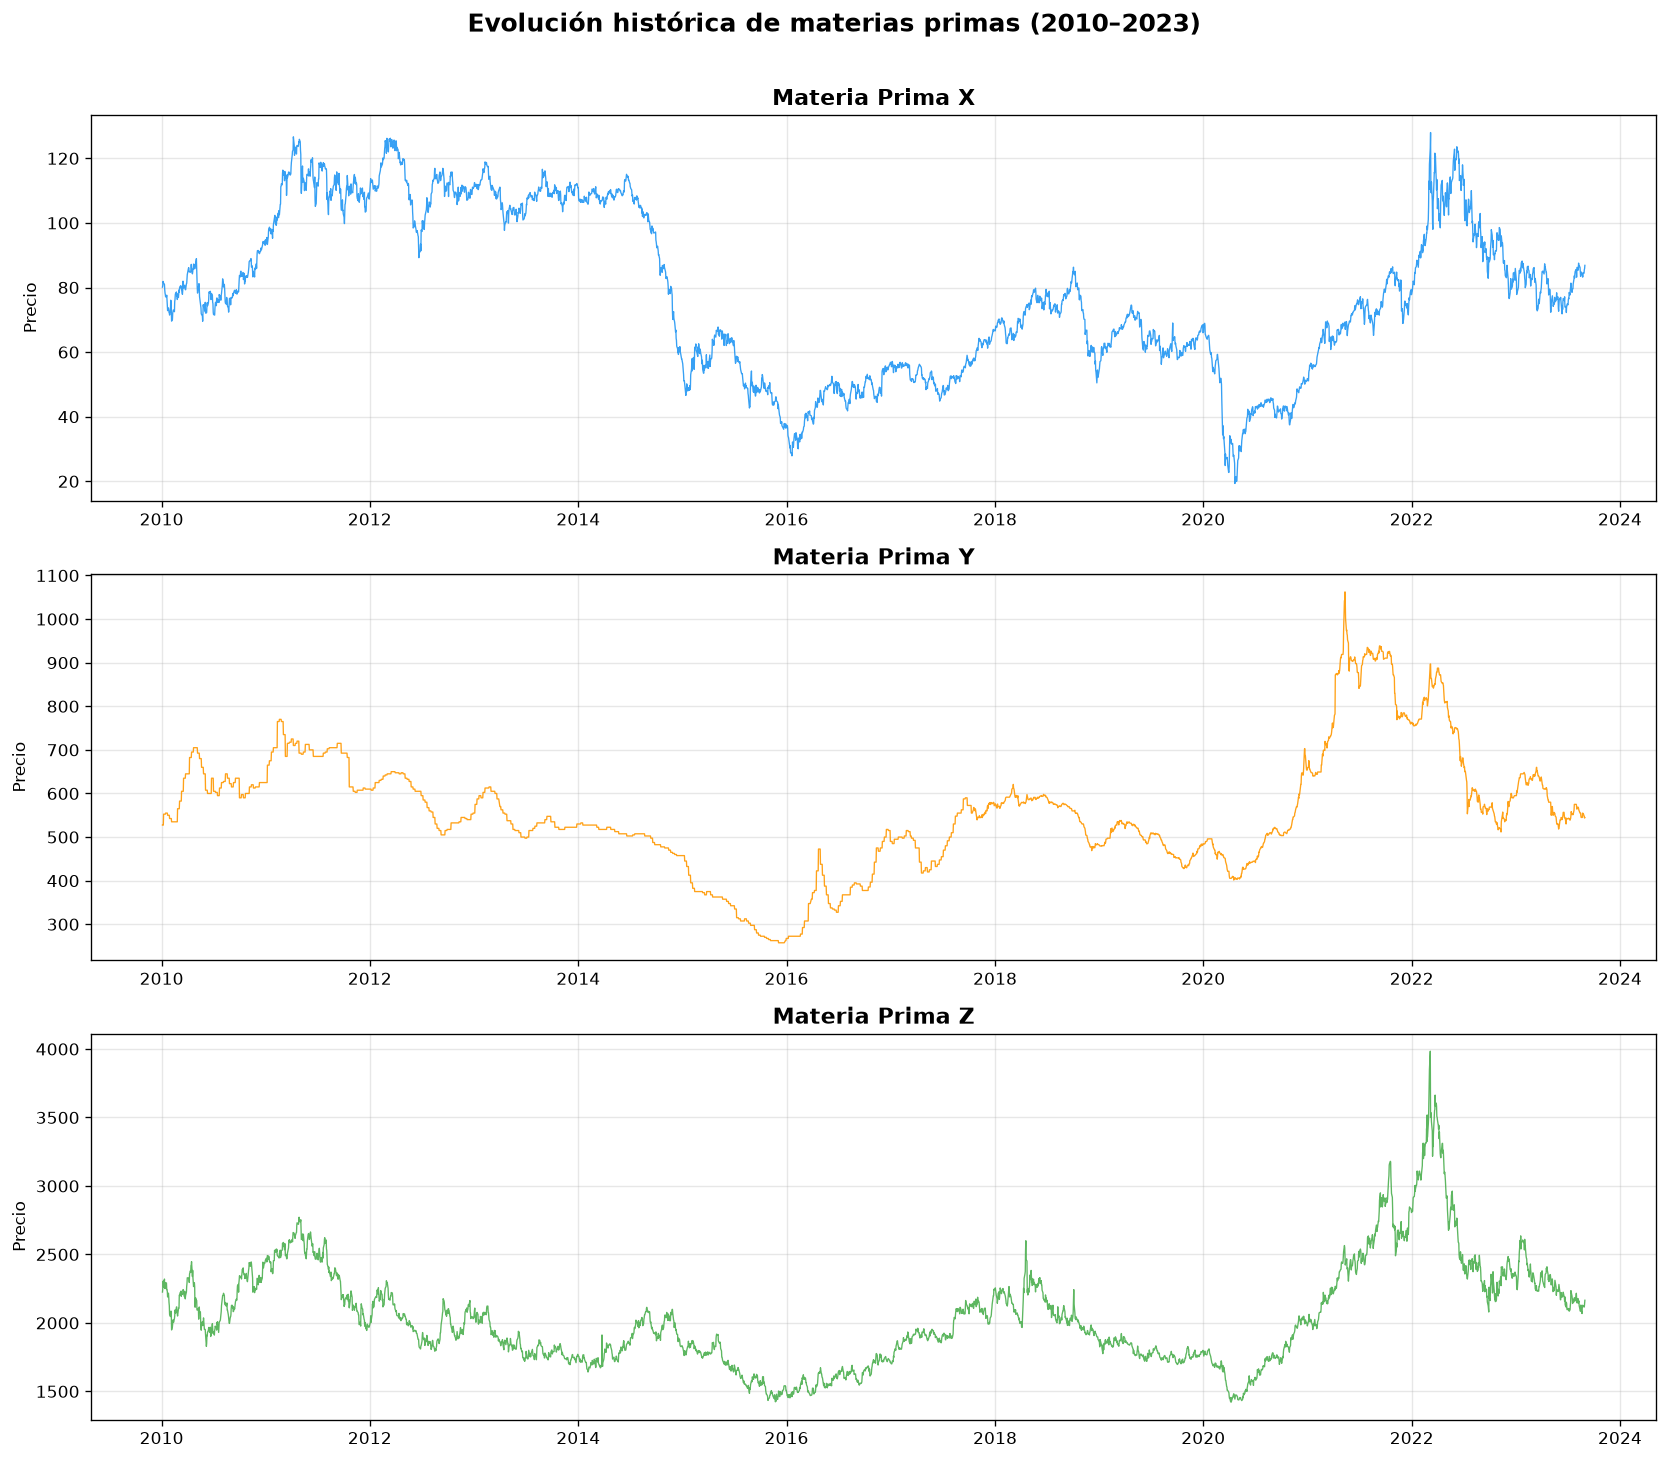

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

variables = [
    ("Price_X", "Materia Prima X", "#2196F3"),
    ("Price_Y", "Materia Prima Y", "#FF9800"),
    ("Price_Z", "Materia Prima Z", "#4CAF50"),
]

for ax, (col, title, color) in zip(axes, variables):
    ax.plot(hist["Date"], hist[col], color=color, linewidth=0.8, alpha=0.9)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Precio")
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle(
    "Evolución histórica de materias primas (2010–2023)",
    fontsize=15,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.show()

In [22]:
# Máximos y mínimos históricos por variable
cols = ["Price_X", "Price_Y", "Price_Z"]

print("=== Máximos y mínimos históricos ===")
for col in cols:
    idx_max = hist[col].idxmax()
    idx_min = hist[col].idxmin()
    print(f"\n{col}:")
    print(f"  Máximo: {hist[col].max():.2f} — fecha: {hist.loc[idx_max, 'Date'].date()}")
    print(f"  Mínimo: {hist[col].min():.2f} — fecha: {hist.loc[idx_min, 'Date'].date()}")

=== Máximos y mínimos históricos ===

Price_X:
  Máximo: 127.98 — fecha: 2022-03-08
  Mínimo: 19.33 — fecha: 2020-04-21

Price_Y:
  Máximo: 1062.37 — fecha: 2021-05-12
  Mínimo: 257.50 — fecha: 2015-12-04

Price_Z:
  Máximo: 3984.00 — fecha: 2022-03-07
  Mínimo: 1421.50 — fecha: 2020-04-08


#### Observaciones visuales — Materias primas

**Materia Prima X (azul):**
- Tendencia alcista 2010–2012, seguida de caída sostenida hasta 2016
- Mínimo histórico de **19.33** el **21 de abril de 2020** — coincide con el impacto del COVID-19
- Recuperación fuerte 2021–2022 con máximo histórico de **127.98** el **8 de marzo de 2022**
- Comportamiento **cíclico sin tendencia clara de largo plazo**

**Materia Prima Y (naranja):**
- Tendencia bajista 2010–2016, con mínimo histórico de **257.50** el **4 de diciembre de 2015**
- Recuperación gradual 2016–2020
- Spike pronunciado con máximo histórico de **1062.37** el **12 de mayo de 2021**
  — posiblemente asociado a disrupciones post-pandemia en cadenas de suministro
- Corrección hacia niveles históricos en 2023

**Materia Prima Z (verde):**
- Comportamiento relativamente estable 2010–2020 
- Mínimo histórico de **1421.50** el **8 de abril de 2020** — coincide con el impacto COVID-19
- Spike muy pronunciado con máximo histórico de **3984.00** el **7 de marzo de 2022**
- Corrección fuerte hacia 2023

> **Insight:** X y Z alcanzan sus mínimos históricos en **abril 2020** y sus máximos
> en **marzo 2022** — con apenas un día de diferencia entre sí. Y alcanza su máximo
> en **mayo 2021**. Este comportamiento sincronizado sugiere una causa común:
> el impacto del COVID-19 y las disrupciones post-pandemia en mercados de materias primas.

### 4.2 Equipos — evolución histórica

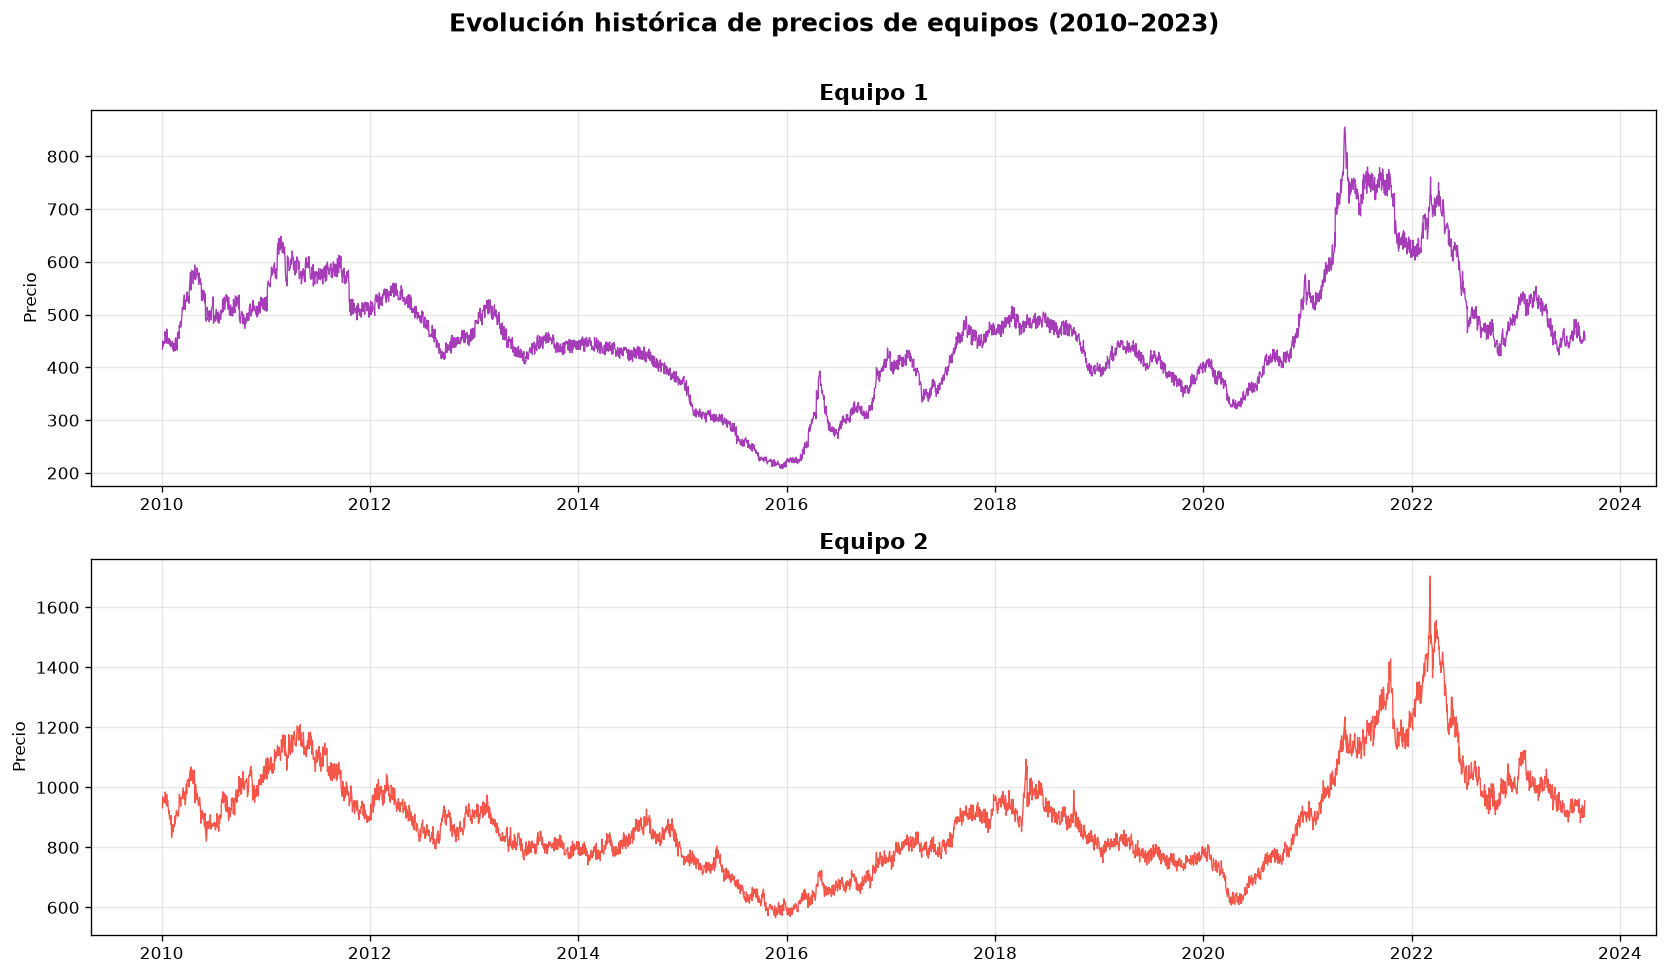

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

variables = [
    ("Price_Equipo1", "Equipo 1", "#9C27B0"),
    ("Price_Equipo2", "Equipo 2", "#F44336"),
]

for ax, (col, title, color) in zip(axes, variables):
    ax.plot(hist["Date"], hist[col], color=color, linewidth=0.8, alpha=0.9)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Precio")
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle(
    "Evolución histórica de precios de equipos (2010–2023)",
    fontsize=15,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.show()

In [24]:
# Máximos y mínimos históricos de equipos
cols = ["Price_Equipo1", "Price_Equipo2"]

print("=== Máximos y mínimos históricos — Equipos ===")
for col in cols:
    idx_max = hist[col].idxmax()
    idx_min = hist[col].idxmin()
    print(f"\n{col}:")
    print(f"  Máximo: {hist[col].max():.2f} — fecha: {hist.loc[idx_max, 'Date'].date()}")
    print(f"  Mínimo: {hist[col].min():.2f} — fecha: {hist.loc[idx_min, 'Date'].date()}")

=== Máximos y mínimos históricos — Equipos ===

Price_Equipo1:
  Máximo: 855.32 — fecha: 2021-05-11
  Mínimo: 208.34 — fecha: 2015-12-18

Price_Equipo2:
  Máximo: 1703.96 — fecha: 2022-03-07
  Mínimo: 566.00 — fecha: 2015-11-24


#### Observaciones visuales — Equipos

**Equipo 1 (morado):**
- Tendencia bajista 2010–2016, con mínimo histórico de **208.34** el **18 de diciembre de 2015**
- Recuperación gradual 2016–2020
- Spike pronunciado con máximo histórico de **855.32** el **11 de mayo de 2021**
- Corrección hacia niveles históricos en 2022–2023

**Equipo 2 (rojo):**
- Tendencia bajista 2010–2016, con mínimo histórico de **566.00** el **24 de noviembre de 2015**
- Recuperación gradual 2016–2020
- Spike muy pronunciado con máximo histórico de **1703.96** el **7 de marzo de 2022**
- Corrección fuerte hacia 2023

> **Insight clave:** Los patrones de los equipos replican casi exactamente
> los patrones de las materias primas:
> - Equipo 1 alcanza su máximo el **11 de mayo de 2021** → Price_Y lo hace el **12 de mayo de 2021** (1 día de diferencia)
> - Equipo 2 alcanza su máximo el **7 de marzo de 2022** → Price_Z lo hace el mismo **7 de marzo de 2022** (mismo día)
>
> Esta sincronía temporal refuerza fuertemente la hipótesis de que
> **Y explica Equipo 1** y **Z explica Equipo 2**.

### 4.3 Comparación visual — Materias primas vs Equipos

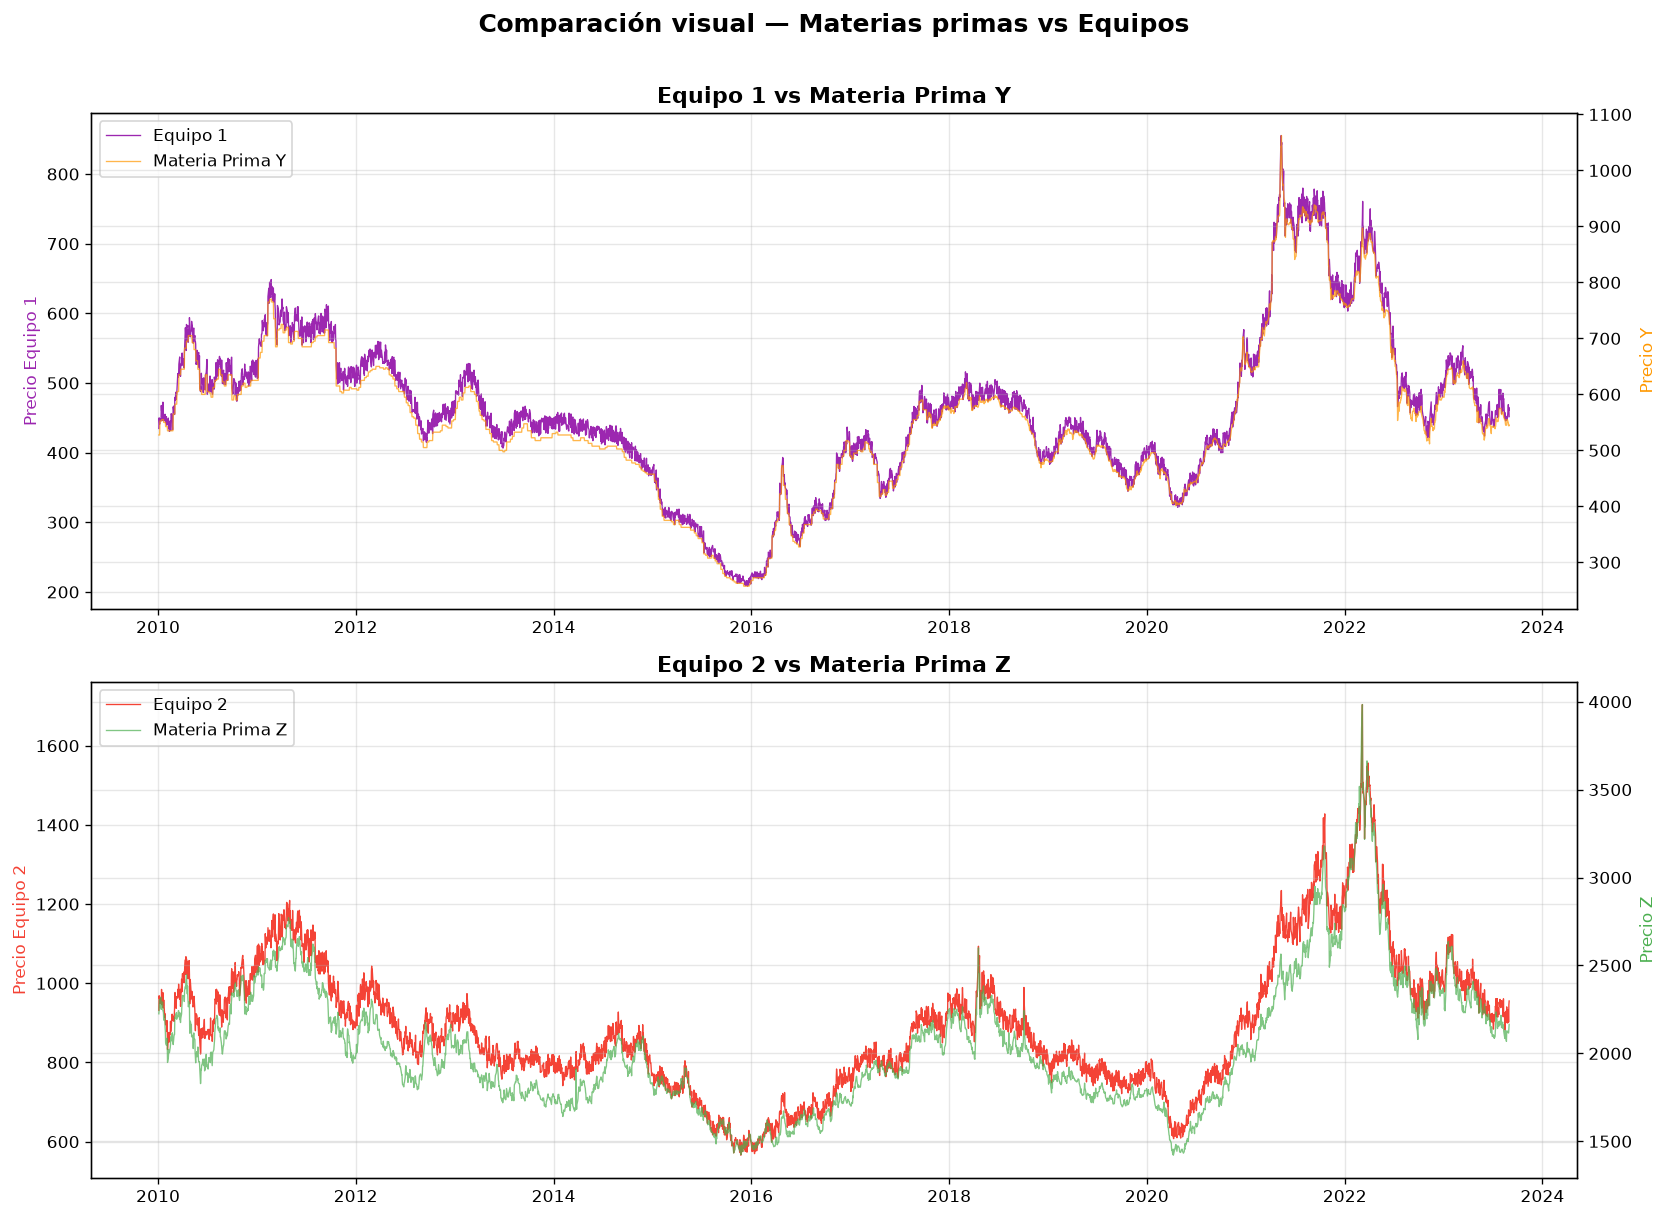

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Equipo 1 vs Y 
ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.plot(hist["Date"], hist["Price_Equipo1"], color="#9C27B0", linewidth=0.8, label="Equipo 1")
ax1_twin.plot(hist["Date"], hist["Price_Y"], color="#FF9800", linewidth=0.8, alpha=0.7, label="Materia Prima Y")
ax1.set_title("Equipo 1 vs Materia Prima Y", fontsize=13, fontweight="bold")
ax1.set_ylabel("Precio Equipo 1", color="#9C27B0")
ax1_twin.set_ylabel("Precio Y", color="#FF9800")
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# Equipo 2 vs Z 
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(hist["Date"], hist["Price_Equipo2"], color="#F44336", linewidth=0.8, label="Equipo 2")
ax2_twin.plot(hist["Date"], hist["Price_Z"], color="#4CAF50", linewidth=0.8, alpha=0.7, label="Materia Prima Z")
ax2.set_title("Equipo 2 vs Materia Prima Z", fontsize=13, fontweight="bold")
ax2.set_ylabel("Precio Equipo 2", color="#F44336")
ax2_twin.set_ylabel("Precio Z", color="#4CAF50")
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, loc="upper left")

plt.suptitle(
    "Comparación visual — Materias primas vs Equipos",
    fontsize=15,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.show()

#### Observaciones visuales — Comparación materias primas vs equipos

**Equipo 1 vs Materia Prima Y:**
- Las curvas son prácticamente indistinguibles a lo largo de todo el período 2010–2023
- Comparten los mismos puntos de inflexión: caída 2010–2016, recuperación 2016–2020,
  spike 2021 y corrección 2022–2023
- La sincronía es tan alta que visualmente parecen la misma serie escalada

**Equipo 2 vs Materia Prima Z:**
- Las curvas siguen el mismo patrón general con alta sincronía
- Se observa una ligera separación vertical constante — Equipo 2 cotiza
  consistentemente por encima de Z en escala relativa
- Comparten los mismos puntos de inflexión: mínimo 2015–2016, spike 2022
  y corrección hacia 2023

> **Conclusión visual:** La relación entre materias primas y equipos
> es visualmente evidente y consistente en el tiempo:
> - **Y → Equipo 1:** relación casi perfecta, curvas prácticamente superpuestas
> - **Z → Equipo 2:** relación muy fuerte con desplazamiento vertical constante
>
> Esta evidencia visual será validada formalmente en el análisis de correlaciones.

## 5. Análisis de Correlaciones

### 5.1 Matriz de correlación de Pearson

La correlación de Pearson mide la relación lineal entre dos variables.
Es el primer paso para identificar qué materias primas están más asociadas
con cada equipo y cuáles podrían ser ruido.

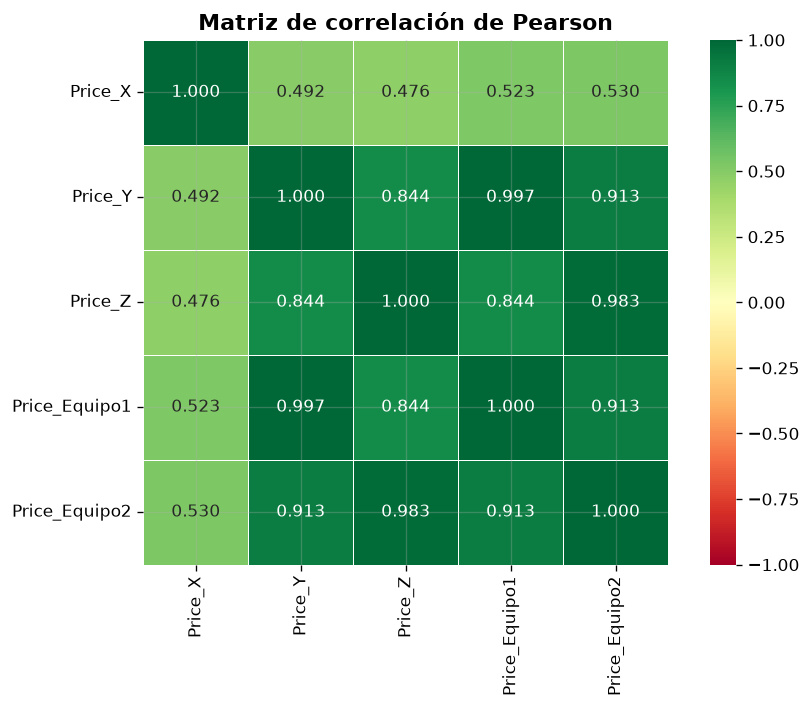

In [26]:
# Matriz de correlación de Pearson
corr_pearson = hist.drop(columns=["Date"]).corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de correlación de Pearson", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### Interpretación — Correlación de Pearson

| Par de variables | Correlación | Interpretación |
|---|---|---|
| Price_Y ↔ Price_Equipo1 | **0.997** | Correlación casi perfecta — señal muy fuerte |
| Price_Z ↔ Price_Equipo2 | **0.983** | Correlación casi perfecta — señal muy fuerte |
| Price_Y ↔ Price_Equipo2 | 0.913 | Correlación muy fuerte |
| Price_Z ↔ Price_Equipo1 | 0.844 | Correlación fuerte |
| Price_Y ↔ Price_Z | 0.844 | Alta correlación entre materias primas — multicolinealidad potencial |
| Price_X ↔ Price_Equipo1 | 0.523 | Correlación moderada |
| Price_X ↔ Price_Equipo2 | 0.530 | Correlación moderada |
| Price_X ↔ Price_Y | 0.492 | Correlación moderada-baja |
| Price_X ↔ Price_Z | 0.476 | Correlación moderada-baja |

> **Advertencia metodológica:** La correlación de Pearson mide relación lineal
> pero es sensible a tendencias compartidas — dos series con tendencia alcista
> pueden aparecer correlacionadas sin tener una relación causal real.
> Por esto complementaremos con correlación de Spearman y análisis de lags.

> **Primeras conclusiones:**
> - **Price_X** es la variable con menor correlación con ambos equipos (0.523 y 0.530)
>   — candidata a ser **ruido** 
> - **Price_Y** domina la explicación del **Equipo 1**
> - **Price_Z** domina la explicación del **Equipo 2**
> - La alta correlación entre Y y Z (0.844) indica **multicolinealidad**
>   que deberá tratarse en el modelado

### 5.2 Correlación de Spearman

A diferencia de Pearson, Spearman mide la relación **monótona** entre variables
(no necesariamente lineal) y es más robusta ante outliers y tendencias compartidas.
Comparar ambas correlaciones nos permite detectar si la relación es genuina
o está inflada por tendencias comunes.

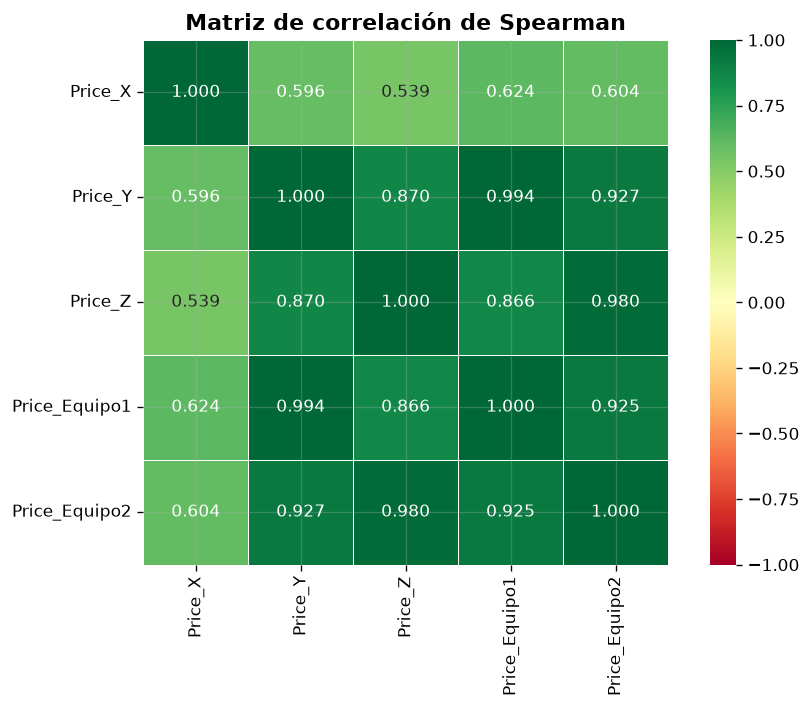

In [27]:
# Matriz de correlación de Spearman
corr_spearman = hist.drop(columns=["Date"]).corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de correlación de Spearman", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 📌 Interpretación — Comparación Pearson vs Spearman

| Par de variables | Pearson | Spearman | Diferencia | Interpretación |
|---|---|---|---|---|
| Price_Y ↔ Price_Equipo1 | 0.997 | 0.994 | 0.003 | Relación genuina y estable |
| Price_Z ↔ Price_Equipo2 | 0.983 | 0.980 | 0.003 | Relación genuina y estable |
| Price_Y ↔ Price_Equipo2 | 0.913 | 0.927 | 0.014 | Relación genuina y estable |
| Price_Z ↔ Price_Equipo1 | 0.844 | 0.866 | 0.022 | Relación genuina y estable |
| Price_X ↔ Price_Equipo1 | 0.523 | 0.624 | 0.101 | Diferencia notable |
| Price_X ↔ Price_Equipo2 | 0.530 | 0.604 | 0.074 | Diferencia notable |

> **Conclusiones clave:**
>
> - Las correlaciones de Y y Z con los equipos son **consistentes entre Pearson y Spearman**
>   — esto confirma que la relación es **genuina** y no está inflada por tendencias compartidas
>
> - Price_X muestra una diferencia notable entre Pearson (0.523) y Spearman (0.624)
>   — Spearman sube porque captura mejor la relación monótona no lineal de X.
>   Sin embargo, sigue siendo la variable con **menor poder explicativo** de las tres
>   materias primas — refuerza su candidatura como **ruido o variable de baja señal**
>
> - La multicolinealidad entre Y y Z se confirma también en Spearman (0.870)
>   — deberá tratarse formalmente con VIF en el notebook 02

## 6. Análisis de Outliers

Los outliers en series de tiempo de precios pueden ser:
- **Outliers reales:** eventos extraordinarios (crisis, pandemias, shocks de mercado)
- **Errores de medición:** datos incorrectos que deben corregirse

Identificarlos es clave para decidir si deben tratarse antes del modelado.
Usaremos el método IQR (Rango Intercuartílico) para detectarlos.

### 6.1 Detección de outliers por método IQR

In [28]:
# Detección de outliers por IQR
cols = ["Price_X", "Price_Y", "Price_Z", "Price_Equipo1", "Price_Equipo2"]

print("=== Detección de outliers — Método IQR ===\n")
outlier_summary = {}

for col in cols:
    Q1 = hist[col].quantile(0.25)
    Q3 = hist[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = hist[(hist[col] < lower) | (hist[col] > upper)]
    outlier_summary[col] = {
        "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "lower": lower, "upper": upper,
        "n_outliers": len(outliers),
        "pct": len(outliers) / len(hist) * 100
    }

    print(f"{col}:")
    print(f"  Límite inferior: {lower:.2f} | Límite superior: {upper:.2f}")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(hist)*100:.2f}%)")
    print()

=== Detección de outliers — Método IQR ===

Price_X:
  Límite inferior: -14.24 | Límite superior: 175.88
  Outliers detectados: 0 (0.00%)

Price_Y:
  Límite inferior: 276.25 | Límite superior: 826.25
  Outliers detectados: 291 (8.24%)

Price_Z:
  Límite inferior: 1064.22 | Límite superior: 2938.97
  Outliers detectados: 90 (2.55%)

Price_Equipo1:
  Límite inferior: 222.16 | Límite superior: 691.68
  Outliers detectados: 223 (6.32%)

Price_Equipo2:
  Límite inferior: 475.57 | Límite superior: 1281.25
  Outliers detectados: 105 (2.97%)



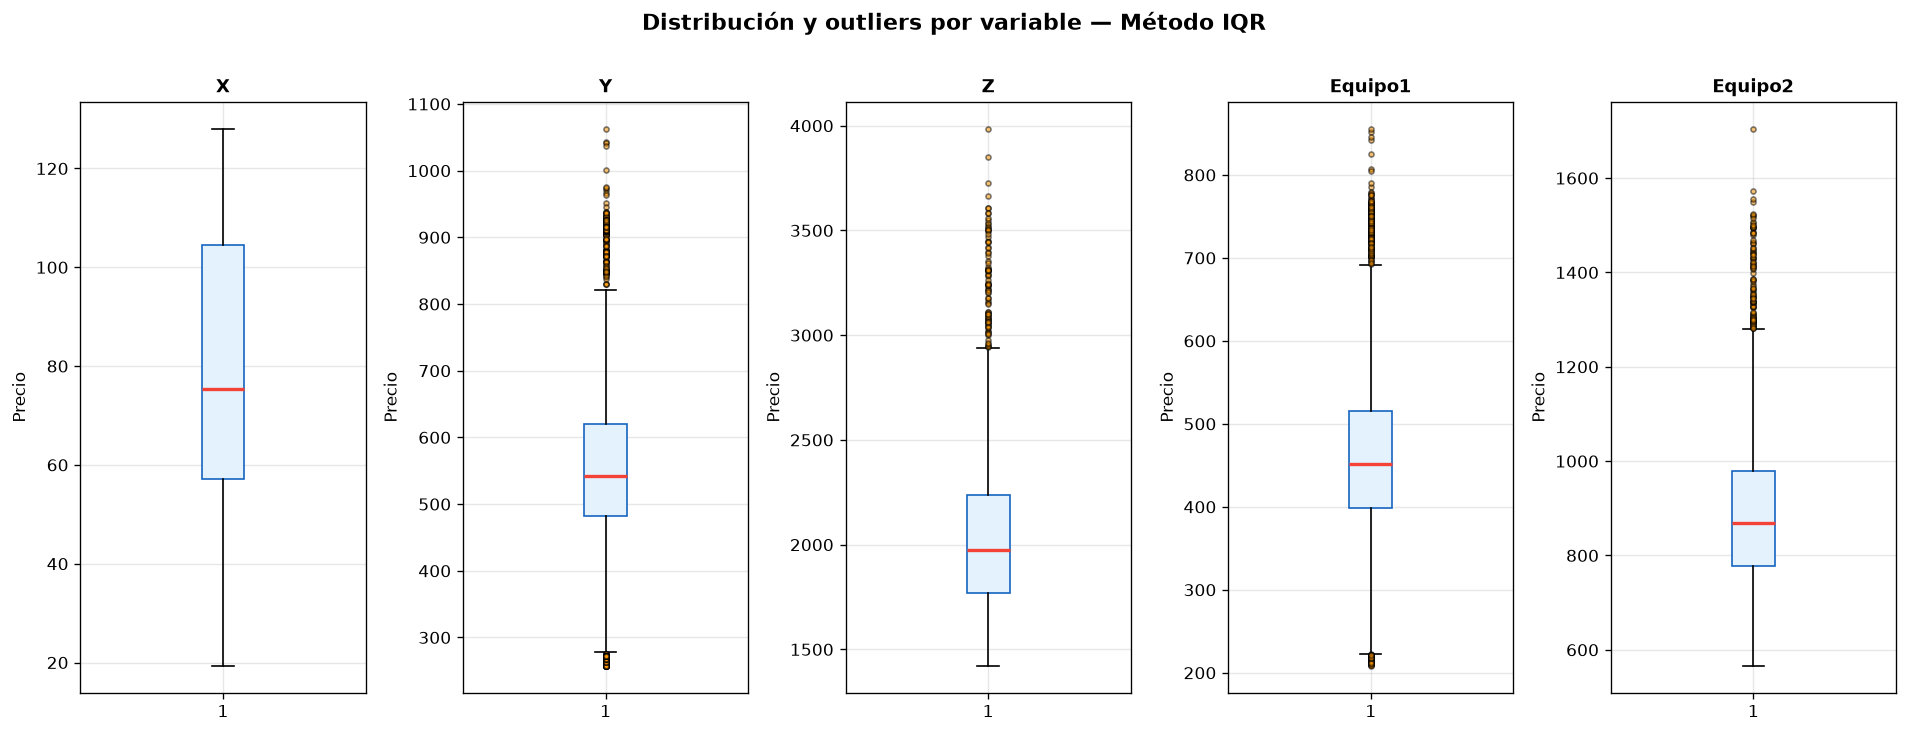

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))

for ax, col in zip(axes, cols):
    ax.boxplot(hist[col], patch_artist=True,
               boxprops=dict(facecolor="#E3F2FD", color="#1565C0"),
               medianprops=dict(color="#F44336", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor="#FF9800",
                               markersize=3, alpha=0.5))
    ax.set_title(col.replace("Price_", ""), fontsize=11, fontweight="bold")
    ax.set_ylabel("Precio")

plt.suptitle(
    "Distribución y outliers por variable — Método IQR",
    fontsize=13,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.show()

In [20]:
# Verificar a qué fechas corresponden los outliers de Price_Y y Price_Equipo1
cols_check = ["Price_Y", "Price_Equipo1", "Price_Z", "Price_Equipo2"]

for col in cols_check:
    Q1 = hist[col].quantile(0.25)
    Q3 = hist[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR

    outliers = hist[hist[col] > upper][["Date", col]]
    if len(outliers) > 0:
        print(f"=== Outliers superiores — {col} ===")
        print(f"  Rango de fechas: {outliers['Date'].min().date()}  {outliers['Date'].max().date()}")
        print(f"  Total: {len(outliers)} registros")
        print()

=== Outliers superiores — Price_Y ===
  Rango de fechas: 2021-04-08  2022-04-22
  Total: 188 registros

=== Outliers superiores — Price_Equipo1 ===
  Rango de fechas: 2021-04-08  2022-04-22
  Total: 177 registros

=== Outliers superiores — Price_Z ===
  Rango de fechas: 2021-09-13  2022-05-23
  Total: 90 registros

=== Outliers superiores — Price_Equipo2 ===
  Rango de fechas: 2021-09-10  2022-05-23
  Total: 105 registros



#### Interpretación — Análisis de outliers

| Variable | Outliers | % | Rango de fechas outliers |
|---|---|---|---|
| Price_X | 0 | 0.00% | — |
| Price_Y | 291 | 8.24% | 2021-04-08 - 2022-04-22 |
| Price_Z | 90 | 2.55% | 2021-09-13 - 2022-05-23 |
| Price_Equipo1 | 223 | 6.32% | 2021-04-08 - 2022-04-22 |
| Price_Equipo2 | 105 | 2.97% | 2021-09-10 - 2022-05-23 |

**Conclusiones:**
- Los outliers **no están dispersos aleatoriamente** en el tiempo — están
  concentrados en períodos específicos y contiguos de 12 a 13 meses
- Price_Y y Price_Equipo1 comparten exactamente el **mismo rango de fechas**
  de outliers (2021-04-08  2022-04-22) — evidencia adicional de su relación directa
- Price_Z y Price_Equipo2 comparten también el **mismo rango de fechas**
  (2021-09-13 → 2022-05-23) — misma evidencia para este par
- Price_X no presenta outliers —  A pesar de mostrar fluctuaciones visuales notorias en
  2020 y 2022, estas se mantuvieron dentro de los límites estadísticos del IQR, confirmando
  una menor volatilidad relativa en comparación con Y y Z.

> **Decisión de tratamiento:**
> Los outliers detectados **no son errores de medición** — corresponden a eventos
> reales de mercado verificados: las disrupciones en cadenas de suministro
> post-pandemia concentradas entre **abril 2021 y mayo 2022**.
> Por lo tanto:
> - **No se eliminarán ni imputarán**
> - Se considerará incluir una **variable dummy** en el modelado que marque
>   el período 2021–2022 como régimen atípico
> - El modelo deberá ser robusto ante estos valores extremos

## 7. Descomposición STL de las series

La descomposición STL (Seasonal and Trend decomposition using Loess) separa
cada serie en tres componentes:
- **Tendencia:** dirección general de largo plazo
- **Estacionalidad:** patrones que se repiten periódicamente
- **Residuo:** variación que no explican los dos anteriores

Esto nos permite entender la estructura de cada serie antes de modelar.

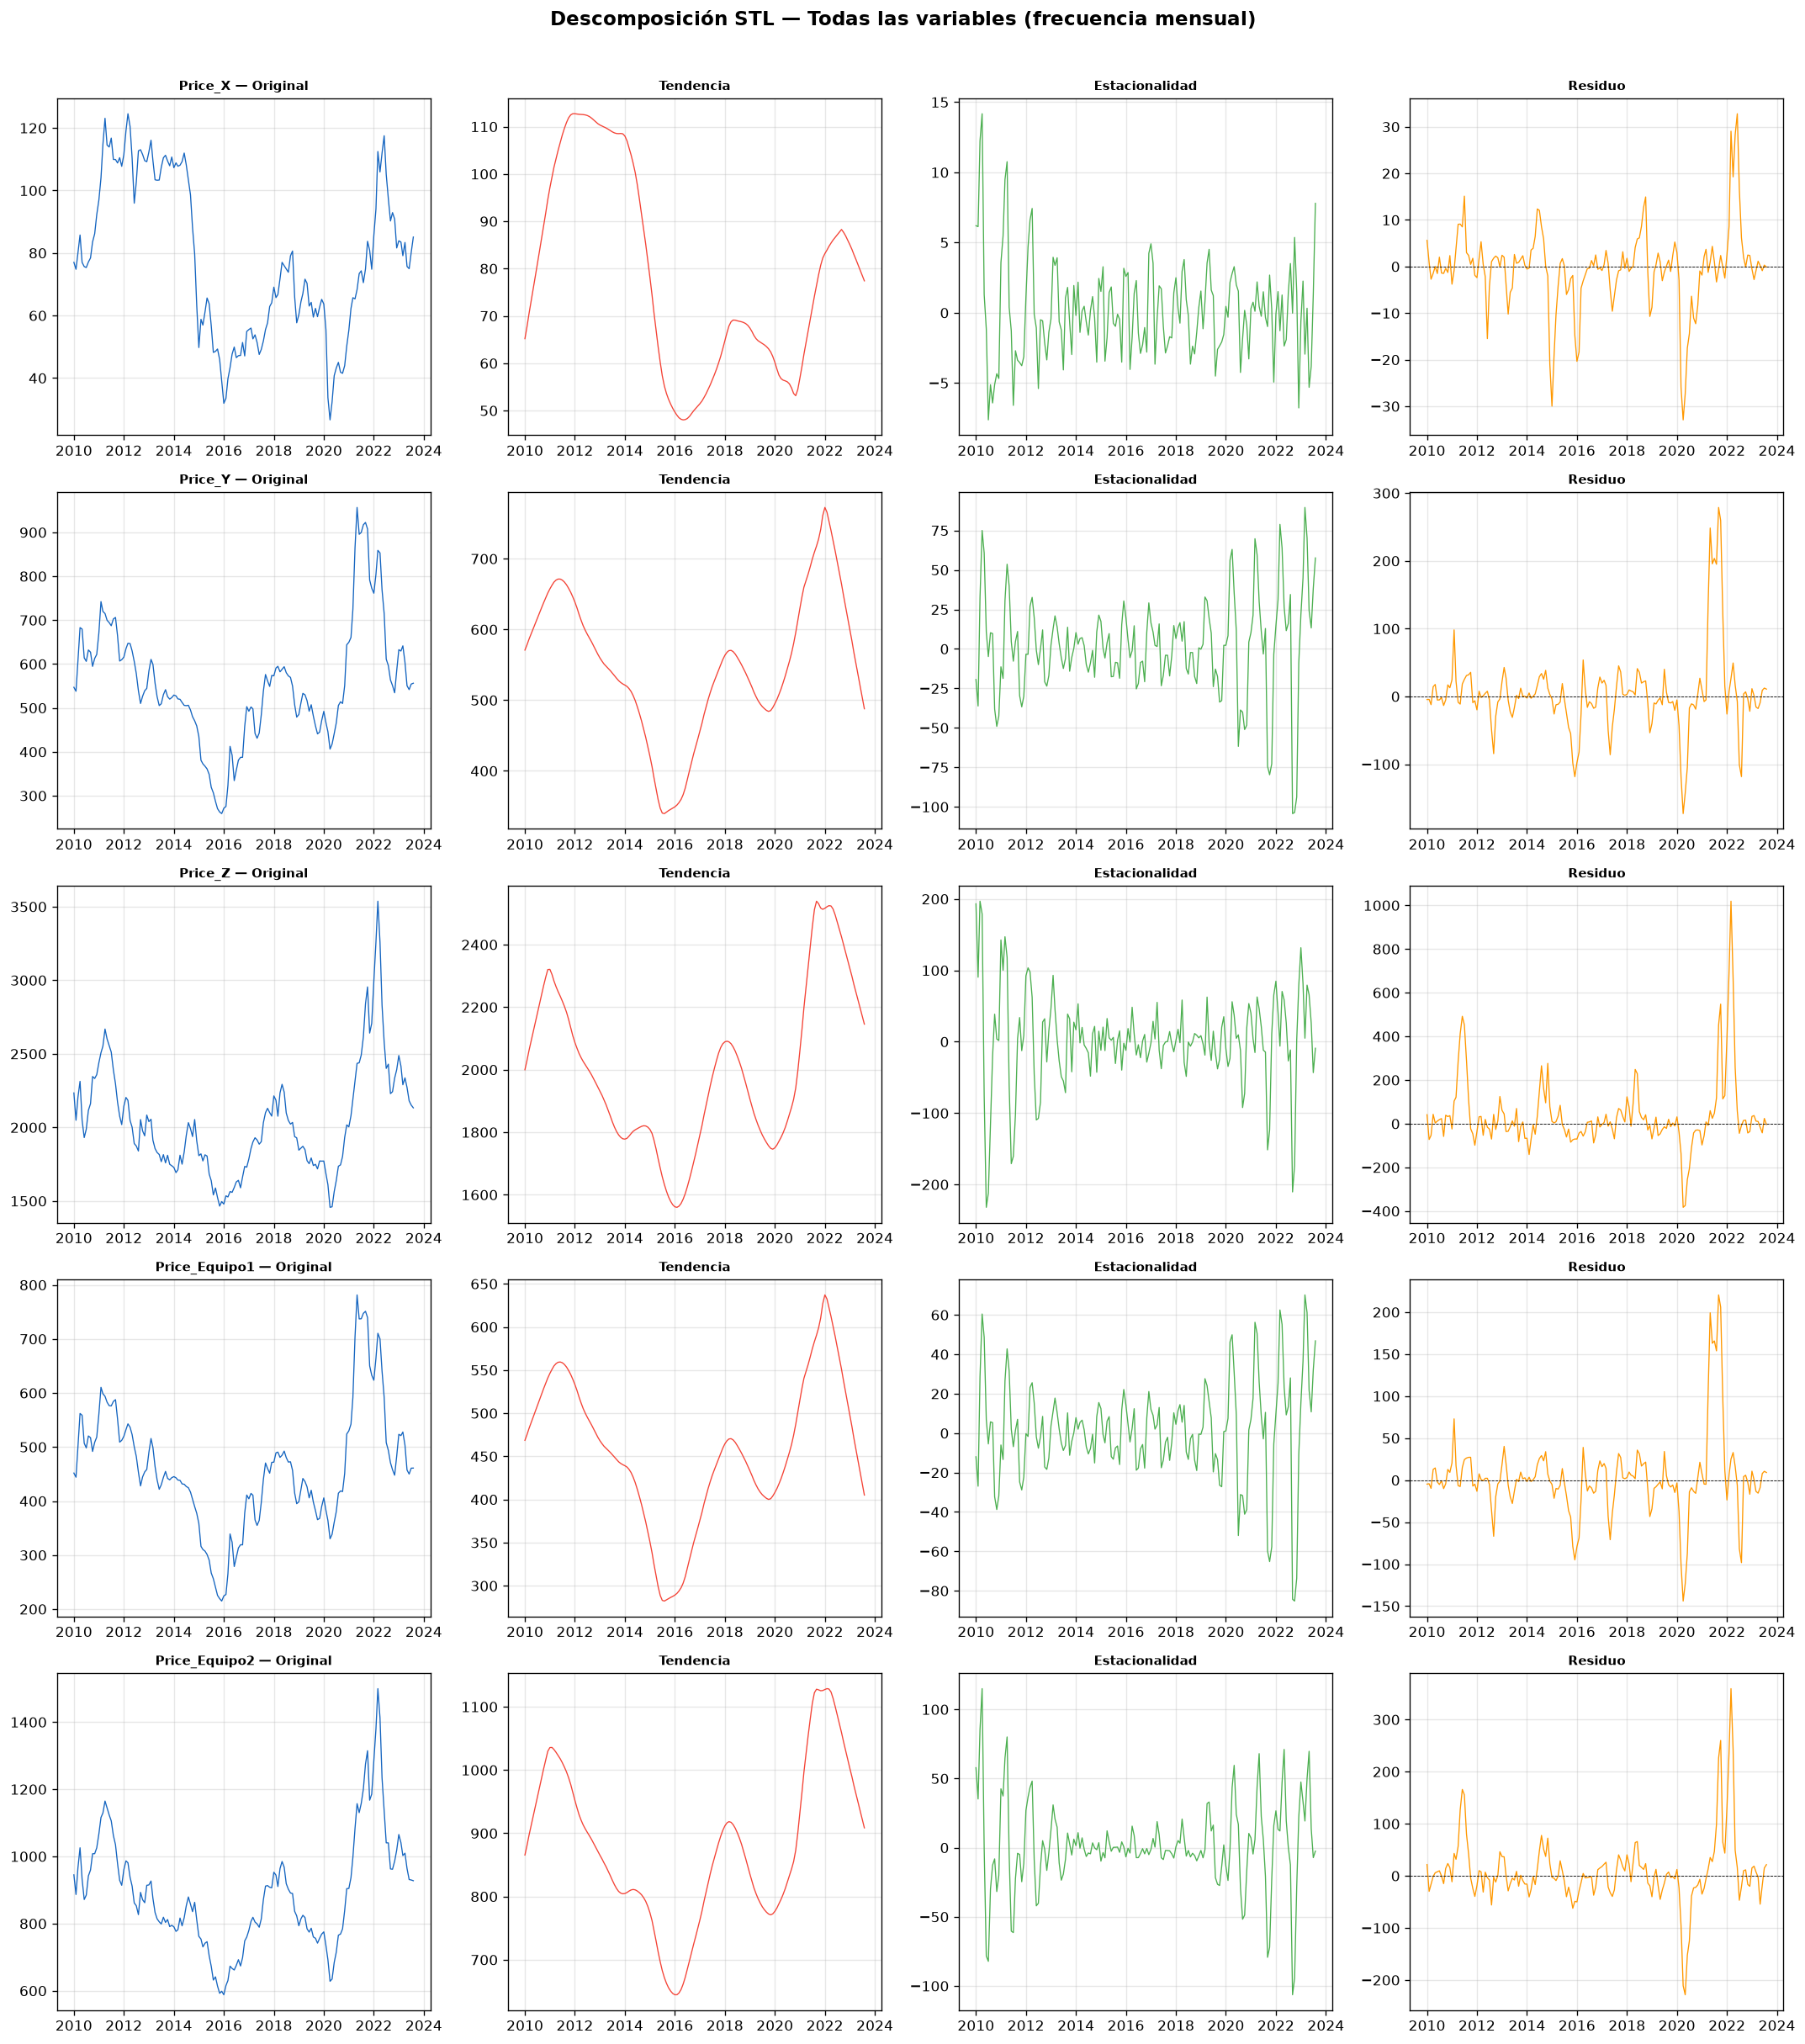

In [31]:
from statsmodels.tsa.seasonal import STL

# Resamplear a frecuencia mensual para la descomposición
# STL requiere una frecuencia regular definida
hist_monthly = hist.set_index("Date").resample("MS").mean()

fig, axes = plt.subplots(5, 4, figsize=(18, 20))

cols = ["Price_X", "Price_Y", "Price_Z", "Price_Equipo1", "Price_Equipo2"]

for i, col in enumerate(cols):
    stl = STL(hist_monthly[col], period=12, robust=True)
    result = stl.fit()

    axes[i, 0].plot(hist_monthly.index, hist_monthly[col], color="#1565C0", linewidth=0.8)
    axes[i, 0].set_title(f"{col} — Original", fontsize=9, fontweight="bold")

    axes[i, 1].plot(hist_monthly.index, result.trend, color="#F44336", linewidth=0.8)
    axes[i, 1].set_title("Tendencia", fontsize=9, fontweight="bold")

    axes[i, 2].plot(hist_monthly.index, result.seasonal, color="#4CAF50", linewidth=0.8)
    axes[i, 2].set_title("Estacionalidad", fontsize=9, fontweight="bold")

    axes[i, 3].plot(hist_monthly.index, result.resid, color="#FF9800", linewidth=0.8)
    axes[i, 3].axhline(0, color="black", linewidth=0.5, linestyle="--")
    axes[i, 3].set_title("Residuo", fontsize=9, fontweight="bold")

plt.suptitle(
    "Descomposición STL — Todas las variables (frecuencia mensual)",
    fontsize=14,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.show()

#### Interpretación — Descomposición STL

**Tendencia:**
- Todas las variables comparten un patrón de tendencia similar:
  alza 2010–2012, caída 2012–2016, recuperación 2016–2020, spike 2021–2022
  y corrección hacia 2023
- Este comportamiento sincronizado refuerza la hipótesis de una causa común
  subyacente (ciclos económicos globales, disrupciones de mercado)

**Estacionalidad:**
- Todas las variables presentan **estacionalidad anual** (período = 12 meses)
- La amplitud estacional es **pequeña relativa a la tendencia** — esto indica
  que la tendencia y los shocks de mercado dominan el comportamiento de los precios
- La estacionalidad de Y y Equipo1 es prácticamente idéntica en forma,
  al igual que Z y Equipo2 — evidencia adicional de sus relaciones

**Residuo:**
- Los residuos de todas las variables muestran un **pico pronunciado en 2021–2022**
  — confirma que el spike post-pandemia no fue capturado completamente
  ni por la tendencia ni por la estacionalidad
- Fuera de ese período, los residuos oscilan cerca de cero — el modelo
  STL captura bien el comportamiento normal de las series

>  **Implicaciones para el modelado:**
> - La **tendencia domina** sobre la estacionalidad — los modelos deben
>   capturar bien los movimientos de largo plazo
> - La **estacionalidad anual existe** pero es secundaria — incluirla
>   mejorará el modelo pero no será el factor determinante
> - El período 2021–2022 es un **régimen atípico** que el modelo debe
>   manejar con cuidado — refuerza la decisión de considerar una variable dummy

## 8. Análisis de Estacionariedad

Una serie es **estacionaria** cuando su media, varianza y autocorrelación
no cambian en el tiempo. Esto es importante porque:
- Muchos modelos de series de tiempo asumen estacionariedad
- Series no estacionarias pueden generar correlaciones espurias
- Si las series no son estacionarias, puede existir una relación de
  **cointegración** (equilibrio de largo plazo) entre ellas

Usaremos dos tests complementarios:
- **ADF (Augmented Dickey-Fuller):** H₀ = la serie tiene raíz unitaria (no estacionaria)
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin):** H₀ = la serie es estacionaria

Interpretar ambos juntos reduce el riesgo de conclusiones erróneas.

### 8.1 Tests ADF y KPSS

In [23]:
import warnings
warnings.filterwarnings("ignore")

In [24]:
from statsmodels.tsa.stattools import adfuller, kpss

cols = ["Price_X", "Price_Y", "Price_Z", "Price_Equipo1", "Price_Equipo2"]

print("=== Tests de Estacionariedad ===\n")
print(f"{'Variable':<15} {'ADF p-value':>12} {'ADF Result':>12} {'KPSS p-value':>13} {'KPSS Result':>12} {'Conclusión':>15}")
print("-" * 85)

for col in cols:
    # ADF test
    adf_result = adfuller(hist[col].dropna(), autolag="AIC")
    adf_pvalue = adf_result[1]
    adf_conclusion = "Estacionaria" if adf_pvalue < 0.05 else "No estacionaria"

    # KPSS test
    kpss_result = kpss(hist[col].dropna(), regression="c", nlags="auto")
    kpss_pvalue = kpss_result[1]
    kpss_conclusion = "Estacionaria" if kpss_pvalue > 0.05 else "No estacionaria"

    # Conclusión combinada
    if adf_conclusion == "Estacionaria" and kpss_conclusion == "Estacionaria":
        conclusion = "Estacionaria"
    elif adf_conclusion == "No estacionaria" and kpss_conclusion == "No estacionaria":
        conclusion = "No estacionaria"
    else:
        conclusion = "Inconcluso"

    print(f"{col:<15} {adf_pvalue:>12.4f} {adf_conclusion:>12} {kpss_pvalue:>13.4f} {kpss_conclusion:>12} {conclusion:>15}")

=== Tests de Estacionariedad ===

Variable         ADF p-value   ADF Result  KPSS p-value  KPSS Result      Conclusión
-------------------------------------------------------------------------------------
Price_X               0.4284 No estacionaria        0.0100 No estacionaria No estacionaria
Price_Y               0.1083 No estacionaria        0.0100 No estacionaria No estacionaria
Price_Z               0.2052 No estacionaria        0.0100 No estacionaria No estacionaria
Price_Equipo1         0.1445 No estacionaria        0.0100 No estacionaria No estacionaria
Price_Equipo2         0.3290 No estacionaria        0.0100 No estacionaria No estacionaria


####  Interpretación — Tests de Estacionariedad

| Variable | ADF p-value | KPSS p-value | Conclusión |
|---|---|---|---|
| Price_X | 0.4284 | 0.0100 |  No estacionaria |
| Price_Y | 0.1083 | 0.0100 |  No estacionaria |
| Price_Z | 0.2052 | 0.0100 |  No estacionaria |
| Price_Equipo1 | 0.1445 | 0.0100 |  No estacionaria |
| Price_Equipo2 | 0.3290 | 0.0100 |  No estacionaria |

**Interpretación de los tests:**
- **ADF:** p-value > 0.05 en todas las variables → no se rechaza H₀
  → todas las series tienen raíz unitaria → no estacionarias
- **KPSS:** p-value = 0.01 en todas las variables → se rechaza H₀
  → todas las series son no estacionarias
- Ambos tests coinciden → conclusión robusta

>  **Implicaciones para el modelado:**
> - Las series **no estacionarias** no pueden usarse directamente en modelos
>   que asumen estacionariedad (como ARIMA simple)
> - Existen dos opciones para tratar la no estacionariedad:
>   1. **Diferenciación:** transformar la serie restando el valor anterior
>   2. **Cointegración:** si las series no estacionarias tienen una relación
>      de equilibrio de largo plazo, se pueden modelar juntas sin diferenciar
> - Dado que las correlaciones entre materias primas y equipos son casi perfectas
>   (0.997 y 0.983), la **cointegración es la hipótesis más probable**
>   y será verificada formalmente en el notebook 02

## 9. Conclusiones del EDA

A continuación se resumen los hallazgos clave que guiarán las decisiones
de modelado en los notebooks siguientes.

### 9.1 Hallazgos principales

**Sobre los datos:**
- `historico_equipos.csv` es el archivo maestro y consolidado exacto de X, Y y Z
  en el rango 2010–2023. Los archivos individuales aportan historia extendida y
  datos post-corte útiles para el forecast
- Todos los archivos tienen granularidad **diaria en días hábiles** — sin datos faltantes
- Y.csv presentó problemas de formato (separador `;`, decimal europeo, formato de fecha)
  que fueron corregidos y documentados

**Sobre las relaciones:**
- **Price_Y → Price_Equipo1:** correlación de Pearson 0.997 y Spearman 0.994
  — relación genuina, casi perfecta y consistente en el tiempo
- **Price_Z → Price_Equipo2:** correlación de Pearson 0.983 y Spearman 0.980
  — relación genuina, casi perfecta y consistente en el tiempo
- **Price_X:** correlación moderada con ambos equipos (0.523 y 0.530 en Pearson)
  — candidata a variable de baja señal o ruido
- Alta correlación entre Y y Z (0.844) indica **multicolinealidad potencial**
  que deberá tratarse en el modelado

**Sobre la estructura temporal:**
- Todas las series son **no estacionarias** (confirmado por ADF y KPSS)
- Todas presentan **estacionalidad anual** de amplitud pequeña relativa a la tendencia
- La **tendencia domina** el comportamiento de todas las series
- El período **2021–2022** representa un régimen atípico (disrupciones post-pandemia)
  verificado con outliers, descomposición STL y fechas exactas

### 9.2 Decisiones para el modelado

| Decisión | Justificación |
|---|---|
| Modelar Equipo1 y Equipo2 por separado | Cada equipo tiene su materia prima dominante |
| Verificar cointegración Y→Equipo1 y Z→Equipo2 | Series no estacionarias con correlación casi perfecta |
| Evaluar exclusión de Price_X | Menor poder explicativo — posible ruido |
| Considerar variable dummy 2021–2022 | Régimen atípico verificado con evidencia |
| Analizar lags entre materias primas y equipos | Puede haber efecto retardado en la transmisión de precios |
| Tratar multicolinealidad Y-Z con VIF | Correlación 0.844 entre predictoras |

## 10. Contexto Metodológico — Comparación de Enfoques

Antes de seleccionar el modelo, comparamos los enfoques técnicos disponibles
para el problema de **predicción de costos industriales a partir de precios
de materias primas**, evaluando su aplicabilidad según las características
encontradas en el EDA:

- Series diarias no estacionarias
- Correlaciones casi perfectas entre predictoras y objetivos (0.997 y 0.983)
- Presencia de outliers concentrados en un período específico (2021–2022)
- Variables exógenas (materias primas) como principales explicadoras

### 10.1 Comparación de enfoques técnicos disponibles


| Enfoque | Descripción | Ventajas | Limitaciones | Aplicabilidad |
|---|---|---|---|---|
| **Regresión OLS** | Regresión lineal clásica con materias primas como predictoras | Simple, interpretable, rápido | No captura estructura temporal ni no estacionariedad | Baseline útil |
| **ARIMAX / SARIMAX** | ARIMA con variables exógenas (materias primas) | Captura autocorrelación y variables externas | Requiere estacionariedad o diferenciación, asume linealidad | Candidato fuerte |
| **VAR** | Vector Autoregression — modela todas las series simultáneamente | Captura interdependencias entre series | Muchos parámetros, sensible a no estacionariedad | Candidato si hay cointegración |
| **VECM** | Vector Error Correction Model — extiende VAR para series cointegradas | Ideal para series no estacionarias cointegradas | Complejo, requiere verificar cointegración formal | Candidato fuerte si se confirma cointegración |
| **XGBoost con features temporales** | Gradient boosting con lags y features de fecha como predictoras | Captura no linealidades, robusto ante outliers | No extrapolación (Los modelos basados en árboles no pueden predecir valores más altos o más bajos que los que ya vieron en el pasado), requiere feature engineering | Candidato fuerte |
| **Prophet** | Modelo aditivo de Facebook para series temporales | Maneja estacionalidad y cambios de tendencia automáticamente | No modela la causalidad bidireccional ni la autocorrelación de los residuos de forma tan robusta como un ARIMAX, y tiende a sobreajustar (overfitting) si las variables externas son muy volátiles | Complementario |
| **LSTM / Redes Neuronales** | Deep learning para series temporales | Captura patrones complejos no lineales | Requiere muchos datos, caja negra, difícil de interpretar | Descartado — datos insuficientes |

### 10.2 Enfoque seleccionado para esta prueba

Dado lo observado en el EDA, la estrategia de modelado será:

1. **Baseline:** Regresión OLS — para tener una referencia simple e interpretable
2. **Modelo principal:** ARIMAX o VECM según resultado del test de cointegración
   — captura la estructura temporal y la relación con las materias primas
3. **Modelo alternativo:** XGBoost con features de lag
   — captura posibles no linealidades y es robusto ante el período atípico 2021-2022
4. **Selección final:** basada en métricas MAE, RMSE y MAPE en conjunto de validación

>  **Justificación:** La combinación de series no estacionarias con correlaciones
> casi perfectas (0.997 y 0.983) hace de la cointegración la hipótesis más probable.
> Si se confirma, VECM es el enfoque estadísticamente más riguroso.
> XGBoost actúa como alternativa no paramétrica que no asume ninguna estructura.

## 11. Guardado de datos procesados

Con el EDA completo y los datos validados, guardamos los archivos limpios
en `data/processed/` listos para el modelado en el notebook 02.

In [26]:
# Guardar datos procesados
PROCESSED = ROOT / "data" / "processed"

# Histórico maestro — ya estaba limpio
hist.to_csv(PROCESSED / "historico_equipos.csv", index=False)

# X — ya estaba limpio
x.to_csv(PROCESSED / "X.csv", index=False)

# Y — con limpieza aplicada (separador, decimal, fecha)
y.to_csv(PROCESSED / "Y.csv", index=False)

# Z — ya estaba limpio
z.to_csv(PROCESSED / "Z.csv", index=False)

print(" Datos procesados guardados en data/processed/")
print()
for f in PROCESSED.iterdir():
    size = f.stat().st_size / 1024
    print(f"  {f.name:<30} {size:.1f} KB")

 Datos procesados guardados en data/processed/

  historico_equipos.csv          159.0 KB
  X.csv                          160.9 KB
  Y.csv                          80.0 KB
  Z.csv                          68.2 KB
